# Decision Tree Worksheet

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

## YOUR CODE HERE

data = pd.read_csv(url, names=names)
data.head()

# Dropping NaN rows
invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)
data.head()

# Splitting data
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

/tmp/ipykernel_1489/1823445129.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [7]:
## YOUR CODE HERE

Decision_tree = DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth = 100, min_samples_leaf = 1)
Decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=100)

Print accuracy of training and validation data.

In [8]:
## YOUR CODE HERE

print(Decision_tree.score(X_train, y_train))
print(Decision_tree.score(X_val, y_val))

1.0
0.8095238095238095


Make a model with a low max-depth and higher minimum sample leafs.

In [9]:
## YOUR CODE HERE

decision_tree2 = DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth = 1, min_samples_leaf = 100)
decision_tree2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=1, min_samples_leaf=100)

Print accuracy of training and validation data.

In [10]:
## YOUR CODE HERE

print(decision_tree2.score(X_train, y_train))
print(decision_tree2.score(X_val, y_val))

0.736
0.7301587301587301


Explain the accuracy results below.

The first model performed better in both testing and validation sets. The second model overfits less and generalizes more because there is only one decision stump. We would have to tune max depth and minimum leaf samples to get the best validation accuracy.

## Metrics

Plot the ROC curve and print the AUC of the second model.

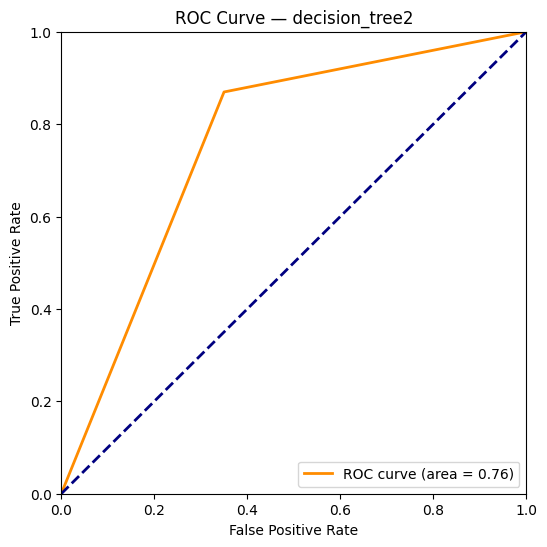

AUC: 0.7597826086956522


In [12]:
## YOUR CODE HERE

# 1. Probability of class 1 for each validation sample
y_val_prob2 = decision_tree2.predict_proba(X_val)[:, 1]

# 2. FPR/TPR across thresholds, and the area under the curve
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob2)
roc_auc = metrics.auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — decision_tree2')
plt.legend(loc='lower right')
plt.show()

print('AUC:', roc_auc)


Use graphviz to visualize your 2nd tree.

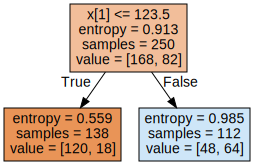

In [14]:
## YOUR CODE HERE

dot_data = tree.export_graphviz(decision_tree2, out_file=None, filled=True)

graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

The column at index n in the training data


Question 2: What is the root feature? Does it make sense as the root feature?

The root feature is plasma glucose. It makes sense as the root feature because the root feature is the feature that best separates the classes and blood sugar is the best indicator of diabetes so it makes sense biologically as well.

Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

Increase training accuracy (up to 1), probably higher test accuracy but the test accuracy would be less than training due to overfitting


**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [15]:
## YOUR CODE HERE

decision_tree3 = DecisionTreeClassifier(criterion = "entropy", random_state = None, max_depth = 500, min_samples_leaf = 1)
decision_tree3.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=500)

In [17]:
print(decision_tree3.score(X_train, y_train))
print(decision_tree3.score(X_val, y_val))

1.0
0.7777777777777778


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [18]:
## YOUR CODE HERE

random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)

RandomForestClassifier()

Print accuracy of training and validation data.

In [19]:
## YOUR CODE HERE

print(random_forest.score(X_train, y_train))
print(random_forest.score(X_val, y_val))

1.0
0.8253968253968254


How did the accuracy compare to the decision tree's accuracy?

Better accuracy

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [21]:
## YOUR CODE HERE

importances = pd.Series(random_forest.feature_importances_, index=X_cols)
print(importances.sort_values(ascending=False).head(3))

plas    0.239127
test    0.161905
age     0.137555
dtype: float64


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

1 trees: 0.667
6 trees: 0.730
11 trees: 0.683
16 trees: 0.778
21 trees: 0.778
26 trees: 0.762
31 trees: 0.810
36 trees: 0.825
41 trees: 0.825
46 trees: 0.794
51 trees: 0.794
56 trees: 0.778
61 trees: 0.778
66 trees: 0.778
71 trees: 0.762
76 trees: 0.778
81 trees: 0.778
86 trees: 0.778
91 trees: 0.778
96 trees: 0.778


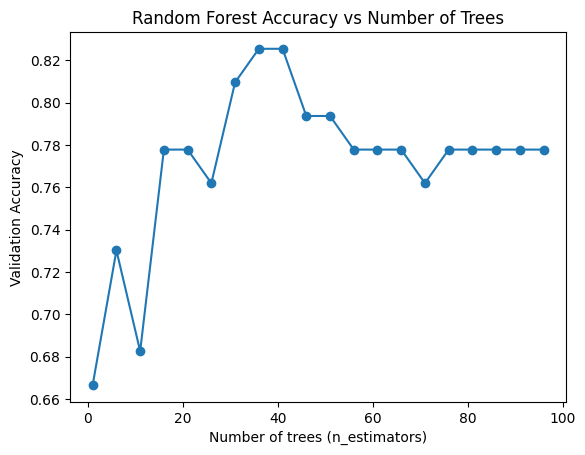

In [22]:
## YOUR CODE HERE
tree_counts = range(1, 101, 5)
accuracies = []

for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=0)
    rf.fit(X_train, y_train)
    acc = rf.score(X_val, y_val)
    accuracies.append(acc)
    print(f'{n} trees: {acc:.3f}')

plt.plot(list(tree_counts), accuracies, marker='o')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Validation Accuracy')
plt.title('Random Forest Accuracy vs Number of Trees')
plt.show()

Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

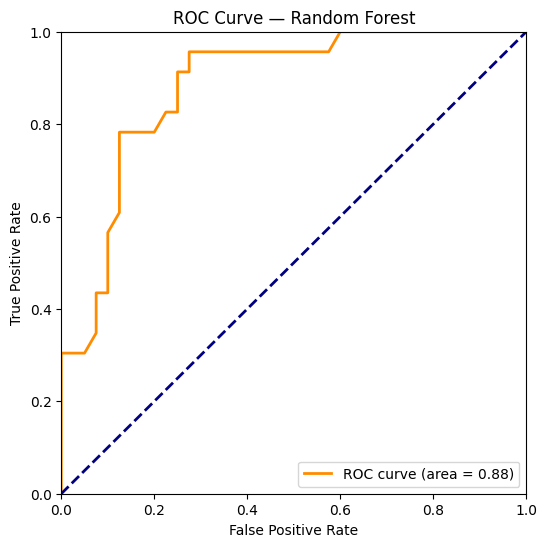

AUC: 0.8826086956521739


In [23]:
## YOUR CODE HERE
y_val_prob = random_forest.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob)
roc_auc = metrics.auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.show()

print('AUC:', roc_auc)